### **We use the prtrained model for glacier mapping**


In [42]:
import os
import torch
import numpy as np
import rasterio as rio
import pandas as pd
from glob import glob
from model import unet
from pyrsimg import imsShow
from pyrsimg import img2patch
from pyrsimg import metrics_segm


In [39]:
dir_val_scene = 'data/watset/ESWD/val/scene' 
dir_val_truth = 'data/watset/ESWD/val/truth' 
dir_result = 'data/watset/ESWD/val_pred'
paths_val_scene = sorted(glob(dir_val_scene+'/*'))
paths_val_truth = sorted(glob(dir_val_truth+'/*'))


In [40]:
## load trained model
path_trained_model = 'model/trained/unet_09532.pth'
model = unet(num_bands=6)
model.load_state_dict(torch.load(path_trained_model, weights_only=True))
model.eval();  ##  



In [44]:
## data prepare: choose one scene for inference
print(len(paths_val_scene))  
# id = np.random.randint(0, len(paths_val_scene))
id = 23
path_scene = paths_val_scene[id]
path_truth = paths_val_truth[id]
scene_id = os.path.basename(path_scene).split('.')[0]
print('scene path:', path_scene)
print('scene id:', scene_id)


31
scene path: data/watset/ESWD/val/scene/S2B_L2A_20190303_N0211_R065_6Bands_S2.tif
scene id: S2B_L2A_20190303_N0211_R065_6Bands_S2


In [45]:
with rio.open(path_truth) as truth_rio:
    truth_arr = truth_rio.read(1)  # (H,W)
    profile_truth = truth_rio.profile
with rio.open(path_scene) as scene_rio:
    scene_arr = scene_rio.read()
    scene_arr = scene_arr.astype(np.float32)/10000
    scene_arr = scene_arr.transpose((1, 2, 0))  # (H,W,C)
scene_arr.shape


(930, 970, 6)

In [46]:
def model_infer(scene_arr, model):
    ### image to patches
    imgPat_obj = img2patch(img=scene_arr, patch_size=512, edge_overlay = 40)
    patch_arr_list = imgPat_obj.toPatch()
    # channel first and numpy array to torch tensor
    patch_list = [torch.from_numpy(patch.transpose(2,0,1)).float() for patch in patch_arr_list]  
    with torch.no_grad():  ## save 
        presult_list = [model(patch[np.newaxis, :]) for patch in patch_list]
    ## channel last and torch tensor to numpy array
    presult_arr_list = [np.squeeze(patch.detach().numpy().transpose(0,2,3,1), axis = 0) 
                                    for patch in presult_list ]       
    ## patch to image
    gla_pred_prob = imgPat_obj.toImage(presult_arr_list)
    gla_pred_cla = np.where(gla_pred_prob>0.5, 1, 0) 
    gla_pred_cla = gla_pred_cla.squeeze().astype(np.uint8) 
    
    return gla_pred_cla

wat_pred_cla = model_infer(scene_arr=scene_arr, model=model) 



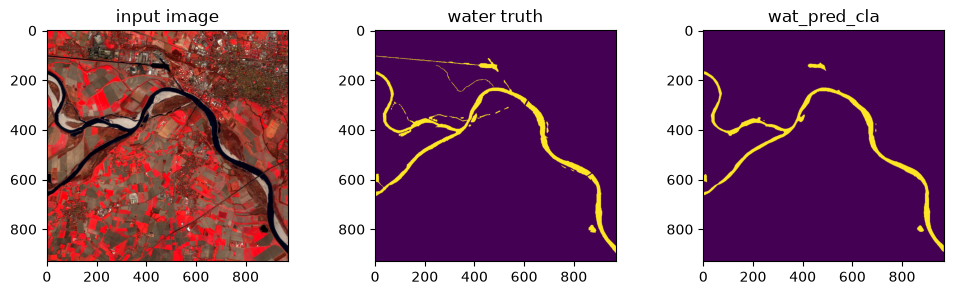

In [47]:
### show the results
imsShow([scene_arr, truth_arr, wat_pred_cla], 
        clip_list=[2, 2, 0], 
        color_bands_list = [[3,2,1], [0,0,0], [0,0,0]],
        img_name_list = ['input image', 'water truth', 'wat_pred_cla'],
        figsize=(12, 3));


In [48]:
metrics_sg = metrics_segm(cla_map=wat_pred_cla, 
                          truth_map=truth_arr, 
                          class_labels=[0, 1],
                          mean_mode=True)
metrics_gla = {'oa': metrics_sg.oa.item(),
               'miou': metrics_sg.iou['labels_mean'].item()}
metrics_gla



{'oa': 0.9904644717880501, 'miou': 0.8928311327803136}

In [ ]:
### batch processing 
metrics_scenes = {}
for path_scene, path_truth in zip(paths_val_scene, paths_val_truth):
    print('scene path:', path_scene)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read(1)  # (H,W)
        profile_truth = truth_rio.profile
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read().transpose((1, 2, 0))  # (H,W,C)
        scene_arr = scene_arr.astype(np.float32)/10000
    wat_pred_cla = model_infer(scene_arr=scene_arr, model=model) 
    metrics_sg = metrics_segm(cla_map=wat_pred_cla, truth_map=truth_arr, 
                              class_labels=[0, 1], mean_mode=True)
    metrics = {'oa': metrics_sg.oa,
                   'miou': metrics_sg.iou['labels_mean']}
    metrics_scenes[path_scene.split('/')[-1].split('.')[0]] = metrics


scene path: data/watset/ESWD/val/scene/S2A_L2A_20190318_N0211_R061_6Bands_S1.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190318_N0211_R061_6Bands_S2.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190318_N0211_R061_6Bands_S3.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190426_N0211_R053_6Bands_S1.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190426_N0211_R053_6Bands_S2.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190426_N0211_R053_6Bands_S3.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190429_N0211_R096_6Bands_S1.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190429_N0211_R096_6Bands_S2.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190429_N0211_R096_6Bands_S3.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190508_N0212_R078_6Bands_S1.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190508_N0212_R078_6Bands_S2.tif
scene path: data/watset/ESWD/val/scene/S2A_L2A_20190508_N0212_R078_6Bands_S3.tif
scene path: data/watset/ESWD

In [ ]:
df_metrics_scenes = pd.DataFrame.from_dict(metrics_scenes, orient='index')
df_metrics_scenes   
# df_metrics_scenes.mean()    


,oa,miou
S2A_L2A_20190318_N0211_R061_6Bands_S1,0.967015,0.790137
S2A_L2A_20190318_N0211_R061_6Bands_S2,0.968186,0.769937
S2A_L2A_20190318_N0211_R061_6Bands_S3,0.970899,0.831970
S2A_L2A_20190426_N0211_R053_6Bands_S1,0.997170,0.993263
S2A_L2A_20190426_N0211_R053_6Bands_S2,0.994858,0.986503
S2A_L2A_20190426_N0211_R053_6Bands_S3,0.997478,0.984142
S2A_L2A_20190429_N0211_R096_6Bands_S1,0.974888,0.911043
S2A_L2A_20190429_N0211_R096_6Bands_S2,0.972908,0.882076
S2A_L2A_20190429_N0211_R096_6Bands_S3,0.975290,0.935025
S2A_L2A_20190508_N0212_R078_6Bands_S1,0.992046,0.977236


### write out prediction map

In [57]:
# ### write the result to path
path_wat_pred_cla = dir_result + '/' + scene_id + '_pred_cla.tif'   ## path to save result
with rio.open(path_wat_pred_cla, 'w', **profile_truth) as dst:
    dst.write(wat_pred_cla, 1)  # write to the first band


array([<Axes: title={'center': 'input image'}>,
       <Axes: title={'center': 'ground truth'}>,
       <Axes: title={'center': 'water prediction'}>], dtype=object)

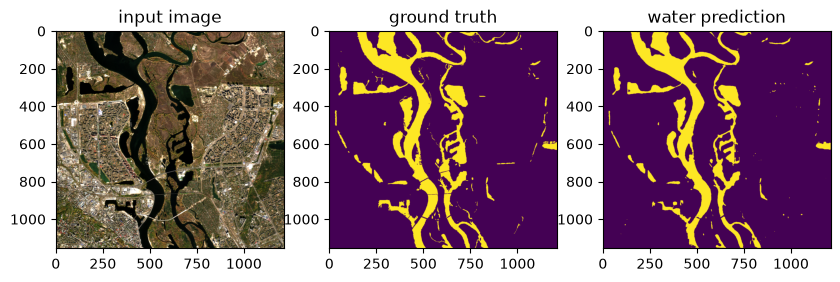

In [59]:
## load and show the image and the prediction map
with rio.open(path_scene) as img_src, rio.open(path_wat_pred_cla) as pred_src, rio.open(path_truth) as truth_src:
        scene_arr = img_src.read().transpose(1, 2, 0)  # change to channel last format
        pred_arr = pred_src.read(1)   # read the first band (the classification result)
        truth_arr = truth_src.read(1)   # read the first band (the ground truth)
imsShow([scene_arr, truth_arr, pred_arr], 
        ['input image', 'ground truth', 'water prediction'], 
        clip_list=[2, 2, 2], 
        figsize=(10, 3))

